# **Brain Tumor CNN**
**Dataset**
https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data?resource=download

**Models**
Xception, ResNet50, InceptionV3











## **Data Preprocessing**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

data_path = '/content/drive/MyDrive/Thesis Data/brain-tumor-data/brain-tumor-mri-dataset'
print(os.listdir(data_path))


['.DS_Store', 'notumor', 'glioma', 'pituitary', 'meningioma']





- Relatively **balanced dataset**

In [ ]:
data_path = '/content/drive/MyDrive/Thesis Data/brain-tumor-data/brain-tumor-mri-dataset'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for cls in classes:
    cls_path = os.path.join(data_path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg'))]
    print(f"{cls.capitalize()}: {len(images)} images")

Glioma: 1641 images
Meningioma: 1775 images
Notumor: 2000 images
Pituitary: 1777 images


**EDA Class Count Bar Chart**
- Notumor, Pituitary, Meningioma, Glioma, respectively.

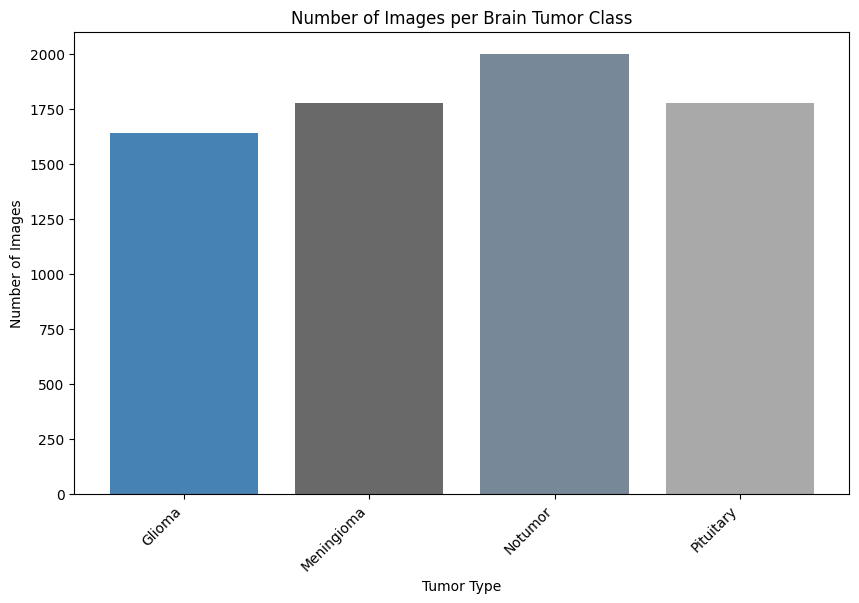

In [ ]:
import matplotlib.pyplot as plt

class_counts = {
   'Glioma': 1641,
    'Meningioma': 1775,
    'Notumor': 2000,
    'Pituitary': 1777
}

plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values(), color=['#4682B4', '#696969', '#778899', '#A9A9A9'])  # Use shades of blue and gray
plt.xlabel('Tumor Type')
plt.ylabel('Number of Images')
plt.title('Number of Images per Brain Tumor Class')

plt.xticks(rotation=45, ha='right')

plt.show()

 **Display Sample Images per Class**

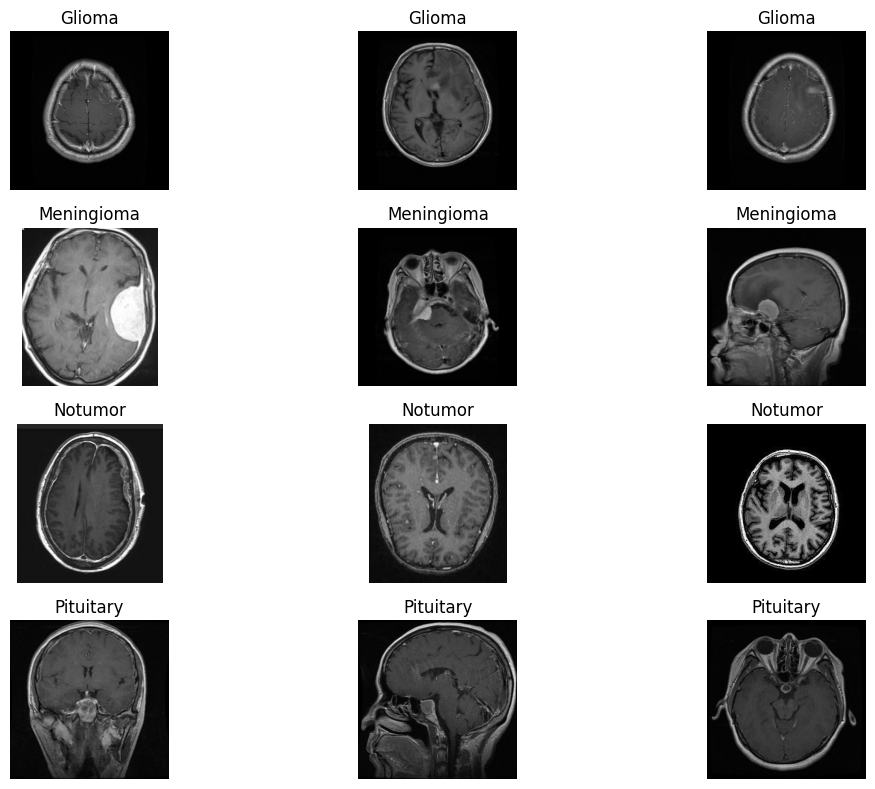

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
data_path = '/content/drive/MyDrive/Thesis Data/brain-tumor-data/brain-tumor-mri-dataset'

plt.figure(figsize=(12, 8))

for i, tumor_class in enumerate(classes):
    class_path = os.path.join(data_path, tumor_class)
    images = os.listdir(class_path)
    sample_imgs = random.sample(images, 3)

    for j, img_name in enumerate(sample_imgs):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(4, 3, i*3 + j + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'{tumor_class.capitalize()}')
        plt.axis('off')

plt.tight_layout()
plt.show()


**Check Image Size to Ensure Consistency**

- Most images are 512×512

 →resize to 224 x 224 since it is the standard for many CNN achitectures such as ResNet

In [ ]:
from PIL import Image
from collections import Counter

image_sizes = []

for tumor_class in classes:
    class_path = os.path.join(data_path, tumor_class)
    images = os.listdir(class_path)
    sample_imgs = random.sample(images, 100)  #

    for img_name in sample_imgs:
        try:
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            continue

print("Top 10 most common image sizes:")
print(Counter(image_sizes).most_common(10))


Top 10 most common image sizes:
[((512, 512), 290), ((225, 225), 12), ((630, 630), 6), ((300, 168), 5), ((236, 236), 4), ((232, 217), 4), ((442, 442), 3), ((214, 236), 3), ((194, 259), 3), ((428, 417), 3)]


In [ ]:
import numpy as np
import cv2
from tensorflow.keras.utils import to_categorical

img_size = 224
X = []
y = []

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
label_map = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

for tumor_class in classes:
    class_path = os.path.join(data_path, tumor_class)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_size, img_size))
            X.append(img)
            y.append(label_map[tumor_class])
        except:
            continue

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X = np.array(X)
y = to_categorical(y, num_classes=4)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (5035, 224, 224, 3) (5035, 4)
Validation set: (1079, 224, 224, 3) (1079, 4)
Test set: (1079, 224, 224, 3) (1079, 4)


**Data Augmentation**
- ONLY used for FINAL IncetpionV3

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator()  # No augmentation for validation or test

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_test_datagen.flow(X_val, y_val, batch_size=32)
test_generator = val_test_datagen.flow(X_test, y_test, batch_size=32, shuffle=False)


# **Model Development**

### **Model Development - Xception**

In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adamax

xception_base = Xception(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

for layer in xception_base.layers:
    layer.trainable = False

x = xception_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
xception_output = Dense(4, activation='softmax')(x)

xception_model = Model(inputs=xception_base.input, outputs=xception_output)

xception_model.compile(optimizer=Adamax(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])


xception_model.summary()


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint('xception_initial.h5', monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = xception_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 262,788 (1.00 MB)

...

158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 310ms/step - accuracy: 0.8809 - loss: 0.3257 - val_accuracy: 0.8777 - val_loss: 0.3088
Epoch 11/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.8783 - loss: 0.3255
Epoch 11: val_loss did not improve from 0.30880
158/158 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.8783 - loss: 0.3255 - val_accuracy: 0.8693 - val_loss: 0.3188
Epoch 12/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.8717 - loss: 0.3344
Epoch 12: val_loss improved from 0.30880 to 0.29368, saving model to xception_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.8717 - loss: 0.3343 - val_accuracy: 0.8832 - val_loss: 0.2937
Epoch 13/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.8826 - loss: 0.3023
Epoch 13: val_loss did not improve from 0.29368
158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 308ms/step - accuracy: 0.8826 - loss: 0.3024 - val_accuracy: 0.8795 - val_loss: 0.3084
Epoch 14/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8867 - loss: 0.3066
Epoch 14: val_loss did not improve from 0.29368
158/158 ━━━━━━━━━━━━━━━━━━━━ 48s 305ms/step - accuracy: 0.8867 - loss: 0.3066 - val_accuracy: 0.8832 - val_loss: 0.2997
Epoch 15/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.8803 - loss: 0.3265
Epoch 15: val_loss did not improve from 0.29368
158/158 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.8803 - loss: 0.3264 - val_accuracy: 0.8814 - val_loss: 0.3063
Epoch 16/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.8868 - loss: 0.3022
Epoch 16: val_loss i

158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 309ms/step - accuracy: 0.8868 - loss: 0.3022 - val_accuracy: 0.8851 - val_loss: 0.2863
Epoch 17/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8891 - loss: 0.2880
Epoch 17: val_loss did not improve from 0.28629
158/158 ━━━━━━━━━━━━━━━━━━━━ 48s 305ms/step - accuracy: 0.8891 - loss: 0.2880 - val_accuracy: 0.8656 - val_loss: 0.3347
Epoch 18/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.8919 - loss: 0.2982
Epoch 18: val_loss did not improve from 0.28629
158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 308ms/step - accuracy: 0.8919 - loss: 0.2982 - val_accuracy: 0.8777 - val_loss: 0.3135
Epoch 19/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.8751 - loss: 0.3059
Epoch 19: val_loss improved from 0.28629 to 0.27522, saving model to xception_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 310ms/step - accuracy: 0.8751 - loss: 0.3059 - val_accuracy: 0.8925 - val_loss: 0.2752
Epoch 20/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.8863 - loss: 0.2928
Epoch 20: val_loss improved from 0.27522 to 0.26745, saving model to xception_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 310ms/step - accuracy: 0.8863 - loss: 0.2928 - val_accuracy: 0.8962 - val_loss: 0.2674
Restoring model weights from the end of the best epoch: 20.


In [ ]:
xception_model.load_weights('xception_initial.h5')

### **Xception Fine-Tuning**

In [ ]:
for layer in xception_base.layers:
    layer.trainable = True


xception_model.compile(optimizer=Adamax(learning_rate=1e-5),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

xception_finetune_checkpoint = ModelCheckpoint('xception_finetuned.h5', monitor='val_loss', save_best_only=True, verbose=1)
xception_finetune_earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

xception_finetune_history = xception_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[xception_finetune_checkpoint, xception_finetune_earlystop]
)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.5849 - loss: 1.1679
Epoch 1: val_loss improved from inf to 0.42354, saving model to xception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 111s 440ms/step - accuracy: 0.5855 - loss: 1.1662 - val_accuracy: 0.8489 - val_loss: 0.4235
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.7792 - loss: 0.5773
Epoch 2: val_loss did not improve from 0.42354
158/158 ━━━━━━━━━━━━━━━━━━━━ 50s 316ms/step - accuracy: 0.7793 - loss: 0.5771 - val_accuracy: 0.8248 - val_loss: 0.4966
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.8535 - loss: 0.4358
Epoch 3: val_loss did not improve from 0.42354
158/158 ━━━━━━━━━━━━━━━━━━━━ 51s 319ms/step - accuracy: 0.8535 - loss: 0.4358 - val_accuracy: 0.8360 - val_loss: 0.4448
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8640 - loss: 0.3788
Epoch 4: val_loss improved from 0.42354 to 0.33766, saving model to xception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 51s 320ms/step - accuracy: 0.8640 - loss: 0.3788 - val_accuracy: 0.8842 - val_loss: 0.3377
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.8730 - loss: 0.3509
Epoch 5: val_loss improved from 0.33766 to 0.29785, saving model to xception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 50s 313ms/step - accuracy: 0.8730 - loss: 0.3509 - val_accuracy: 0.8925 - val_loss: 0.2979
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8734 - loss: 0.3274
Epoch 6: val_loss improved from 0.29785 to 0.27458, saving model to xception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 51s 319ms/step - accuracy: 0.8734 - loss: 0.3274 - val_accuracy: 0.9018 - val_loss: 0.2746
Epoch 7/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8829 - loss: 0.3040
Epoch 7: val_loss improved from 0.27458 to 0.25941, saving model to xception_finetuned.h5


...

158/158 ━━━━━━━━━━━━━━━━━━━━ 51s 321ms/step - accuracy: 0.9368 - loss: 0.1793 - val_accuracy: 0.9323 - val_loss: 0.1805
Epoch 17/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9432 - loss: 0.1594
Epoch 17: val_loss improved from 0.18050 to 0.17260, saving model to xception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 51s 321ms/step - accuracy: 0.9432 - loss: 0.1594 - val_accuracy: 0.9388 - val_loss: 0.1726
Epoch 18/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9451 - loss: 0.1534
Epoch 18: val_loss improved from 0.17260 to 0.17019, saving model to xception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 51s 319ms/step - accuracy: 0.9452 - loss: 0.1533 - val_accuracy: 0.9370 - val_loss: 0.1702
Epoch 19/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9505 - loss: 0.1402
Epoch 19: val_loss improved from 0.17019 to 0.16354, saving model to xception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 50s 316ms/step - accuracy: 0.9505 - loss: 0.1402 - val_accuracy: 0.9425 - val_loss: 0.1635
Epoch 20/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9502 - loss: 0.1372
Epoch 20: val_loss improved from 0.16354 to 0.16124, saving model to xception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 51s 320ms/step - accuracy: 0.9502 - loss: 0.1372 - val_accuracy: 0.9435 - val_loss: 0.1612
Restoring model weights from the end of the best epoch: 20.


### **Xception Test Set Results**

In [ ]:
from tensorflow.keras.models import load_model

best_xception_model = load_model('xception_finetuned.h5')

test_loss, test_acc = best_xception_model.evaluate(test_generator, verbose=1)
print(f" Test Accuracy: {test_acc:.4f}")
print(f" Test Loss: {test_loss:.4f}")


34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9686 - loss: 0.0973
✅ Test Accuracy: 0.9611
📉 Test Loss: 0.1107


**Xception GradCAM Testing**


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


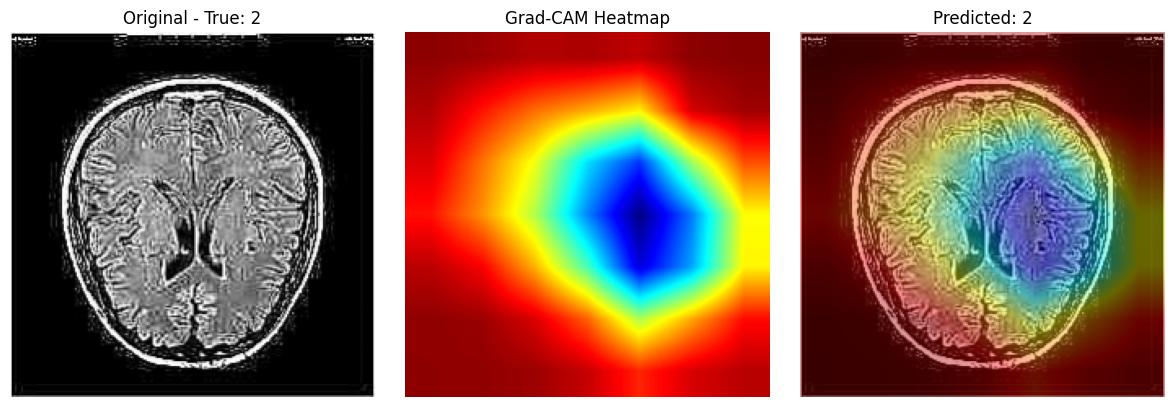

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

model = tf.keras.models.load_model('xception_finetuned.h5')

last_conv_layer_name = 'block14_sepconv2_act'

img_index = 10
img = X_test[img_index]
img_array = np.expand_dims(img, axis=0)

true_label = np.argmax(y_test[img_index])

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer_name).output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    predicted_class = tf.argmax(predictions[0])
    loss = predictions[:, predicted_class]


grads = tape.gradient(loss, conv_outputs)


pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))


conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = np.maximum(heatmap, 0)
heatmap /= tf.math.reduce_max(heatmap)

img_original = (img * 255).astype("uint8")
heatmap = cv2.resize(heatmap.numpy(), (img_original.shape[1], img_original.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_original)
plt.title(f"Original - True: {true_label}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Predicted: {predicted_class.numpy()}")
plt.axis('off')

plt.tight_layout()
plt.show()


**Xception Accuracy and Loss Plots**

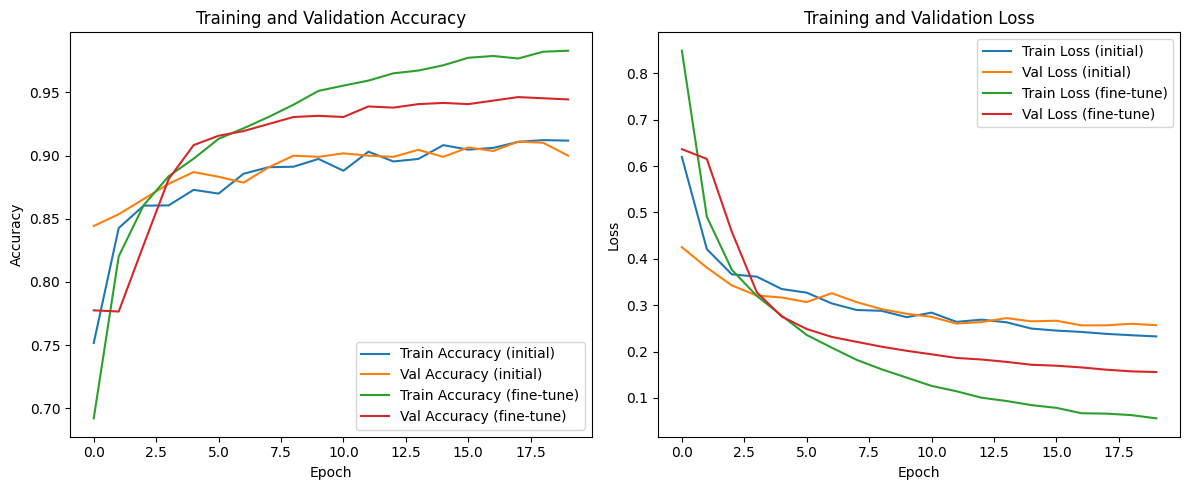

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy (initial)')
plt.plot(history.history['val_accuracy'], label='Val Accuracy (initial)')
plt.plot(xception_finetune_history.history['accuracy'], label='Train Accuracy (fine-tune)')
plt.plot(xception_finetune_history.history['val_accuracy'], label='Val Accuracy (fine-tune)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss (initial)')
plt.plot(history.history['val_loss'], label='Val Loss (initial)')
plt.plot(xception_finetune_history.history['loss'], label='Train Loss (fine-tune)')
plt.plot(xception_finetune_history.history['val_loss'], label='Val Loss (fine-tune)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


The training and validation curves show a healthy training process, with continuous improvements after fine-tuning. Validation accuracy increased alongside training accuracy, and validation loss decreased consistently, indicating that the model was not overfitting and that deeper layers in Xception contributed positively to performance. Loss reduction confirms that fine-tuning helped the model optimize better, and validation loss decreasing shows it's not overfitting.

## **Model Development - ResNet50**

In [ ]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

for layer in resnet_base.layers:
    layer.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
resnet_output = Dense(4, activation='softmax')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=resnet_output)

resnet_model.compile(optimizer=Adamax(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

resnet_model.summary()


resnet_checkpoint = ModelCheckpoint('resnet_initial.h5', monitor='val_loss', save_best_only=True, verbose=1) #saves best model in resnet_initial.h5 file
resnet_early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

resnet_history = resnet_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[resnet_checkpoint, resnet_early_stop]
)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

...

158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6186 - loss: 0.9103 - val_accuracy: 0.6886 - val_loss: 0.8161
Epoch 12/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6234 - loss: 0.9020
Epoch 12: val_loss did not improve from 0.81611
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6234 - loss: 0.9020 - val_accuracy: 0.6293 - val_loss: 0.8737
Epoch 13/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6280 - loss: 0.8878
Epoch 13: val_loss improved from 0.81611 to 0.81373, saving model to resnet_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6281 - loss: 0.8878 - val_accuracy: 0.6821 - val_loss: 0.8137
Epoch 14/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6495 - loss: 0.8691
Epoch 14: val_loss improved from 0.81373 to 0.78922, saving model to resnet_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6494 - loss: 0.8691 - val_accuracy: 0.6886 - val_loss: 0.7892
Epoch 15/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6389 - loss: 0.8754
Epoch 15: val_loss did not improve from 0.78922
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6389 - loss: 0.8755 - val_accuracy: 0.6719 - val_loss: 0.8218
Epoch 16/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6395 - loss: 0.8728
Epoch 16: val_loss did not improve from 0.78922
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6395 - loss: 0.8728 - val_accuracy: 0.6914 - val_loss: 0.7898
Epoch 17/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6435 - loss: 0.8583
Epoch 17: val_loss improved from 0.78922 to 0.76840, saving model to resnet_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6436 - loss: 0.8582 - val_accuracy: 0.7099 - val_loss: 0.7684
Epoch 18/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6346 - loss: 0.8731
Epoch 18: val_loss did not improve from 0.76840
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6347 - loss: 0.8730 - val_accuracy: 0.6580 - val_loss: 0.8196
Epoch 19/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6293 - loss: 0.8738
Epoch 19: val_loss improved from 0.76840 to 0.75451, saving model to resnet_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6294 - loss: 0.8737 - val_accuracy: 0.7118 - val_loss: 0.7545
Epoch 20/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6481 - loss: 0.8386
Epoch 20: val_loss did not improve from 0.75451
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6481 - loss: 0.8387 - val_accuracy: 0.7044 - val_loss: 0.7595
Restoring model weights from the end of the best epoch: 19.


In [ ]:
resnet_model.load_weights('resnet_initial.h5')

### **Fine-Tuning ResNet50**

In [ ]:
for layer in resnet_base.layers:
    layer.trainable = True

resnet_model.compile(optimizer=Adamax(learning_rate=1e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

resnet_finetune_checkpoint = ModelCheckpoint('resnet_finetuned.h5', monitor='val_loss', save_best_only=True, verbose=1)
resnet_finetune_earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

resnet_finetune_history = resnet_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[resnet_finetune_checkpoint, resnet_finetune_earlystop]
)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.3101 - loss: 24.8809
Epoch 1: val_loss improved from inf to 38.88759, saving model to resnet_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 86s 228ms/step - accuracy: 0.3106 - loss: 24.8293 - val_accuracy: 0.2780 - val_loss: 38.8876
Epoch 2/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5750 - loss: 5.1780
Epoch 2: val_loss did not improve from 38.88759
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.5754 - loss: 5.1651 - val_accuracy: 0.2780 - val_loss: 46.8435
Epoch 3/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6964 - loss: 2.2147
Epoch 3: val_loss did not improve from 38.88759
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.6969 - loss: 2.2102 - val_accuracy: 0.2780 - val_loss: 40.1929
Epoch 4/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7843 - loss: 1.3351
Epoch 4: val_loss improved from 38.88759 to 32.02840, saving model to resnet_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7844 - loss: 1.3336 - val_accuracy: 0.2780 - val_loss: 32.0284
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8178 - loss: 0.9237
Epoch 5: val_loss improved from 32.02840 to 26.42485, saving model to resnet_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.8178 - loss: 0.9237 - val_accuracy: 0.2780 - val_loss: 26.4248
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8484 - loss: 0.7242
Epoch 6: val_loss improved from 26.42485 to 18.74216, saving model to resnet_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8484 - loss: 0.7238 - val_accuracy: 0.2780 - val_loss: 18.7422
Epoch 7/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8644 - loss: 0.5999
Epoch 7: val_loss improved from 18.74216 to 11.05434, saving model to resnet_finetuned.h5


...

158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9272 - loss: 0.2186 - val_accuracy: 0.9453 - val_loss: 0.5004
Epoch 16/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9360 - loss: 0.2058
Epoch 16: val_loss improved from 0.50040 to 0.48376, saving model to resnet_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9360 - loss: 0.2056 - val_accuracy: 0.9444 - val_loss: 0.4838
Epoch 17/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9425 - loss: 0.1827
Epoch 17: val_loss improved from 0.48376 to 0.47951, saving model to resnet_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9425 - loss: 0.1827 - val_accuracy: 0.9453 - val_loss: 0.4795
Epoch 18/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9460 - loss: 0.1615
Epoch 18: val_loss did not improve from 0.47951
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9460 - loss: 0.1615 - val_accuracy: 0.9490 - val_loss: 0.5035
Epoch 19/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9560 - loss: 0.1312
Epoch 19: val_loss improved from 0.47951 to 0.45706, saving model to resnet_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9560 - loss: 0.1312 - val_accuracy: 0.9527 - val_loss: 0.4571
Epoch 20/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9597 - loss: 0.1112
Epoch 20: val_loss improved from 0.45706 to 0.45592, saving model to resnet_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9597 - loss: 0.1112 - val_accuracy: 0.9472 - val_loss: 0.4559
Restoring model weights from the end of the best epoch: 20.


### **ResNet50 Test Set Results**

In [ ]:
from tensorflow.keras.models import load_model

resnet_model = load_model('resnet_finetuned.h5')

resnet_test_loss, resnet_test_acc = resnet_model.evaluate(X_test, y_test, verbose=1)
print(f" ResNet Test Accuracy: {resnet_test_acc:.4f}")
print(f" ResNet Test Loss: {resnet_test_loss:.4f}")


34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9602 - loss: 0.1553
✅ ResNet Test Accuracy: 0.9601
📉 ResNet Test Loss: 0.1563


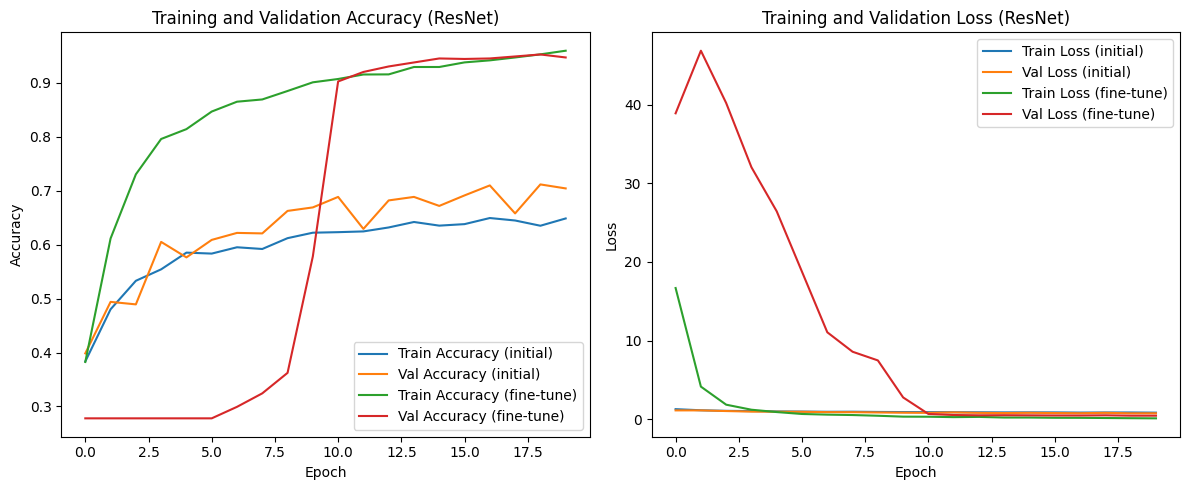

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['accuracy'], label='Train Accuracy (initial)')
plt.plot(resnet_history.history['val_accuracy'], label='Val Accuracy (initial)')
plt.plot(resnet_finetune_history.history['accuracy'], label='Train Accuracy (fine-tune)')
plt.plot(resnet_finetune_history.history['val_accuracy'], label='Val Accuracy (fine-tune)')
plt.title('Training and Validation Accuracy (ResNet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['loss'], label='Train Loss (initial)')
plt.plot(resnet_history.history['val_loss'], label='Val Loss (initial)')
plt.plot(resnet_finetune_history.history['loss'], label='Train Loss (fine-tune)')
plt.plot(resnet_finetune_history.history['val_loss'], label='Val Loss (fine-tune)')
plt.title('Training and Validation Loss (ResNet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


### **Model Development - InceptionV3**
**First Inception Version**

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adamax

inception_base = InceptionV3(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

for layer in inception_base.layers:
    layer.trainable = False

x = inception_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
inception_output = Dense(4, activation='softmax')(x)

inception_model = Model(inputs=inception_base.input, outputs=inception_output)

inception_model.compile(optimizer=Adamax(learning_rate=0.001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

inception_model.summary()

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint('inception_initial.h5', monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = inception_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

### **First Fine-Tuning: InceptionV3**

In [ ]:
for layer in inception_base.layers:
    layer.trainable = True

inception_model.compile(optimizer=Adamax(learning_rate=1e-5),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

inception_finetune_checkpoint = ModelCheckpoint('inception_finetuned.h5', monitor='val_loss', save_best_only=True, verbose=1)
inception_finetune_earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

inception_finetune_history = inception_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[inception_finetune_checkpoint, inception_finetune_earlystop]
)

### **Initial Model Comparison**

In [ ]:
import pandas as pd

model_names = ['Xception', 'ResNet50', 'InceptionV3']
test_accuracies = [0.9574, 0.9601, 0.9648]
test_losses = [0.1096, 0.1563, 0.0988]

results_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': test_accuracies,
    'Test Loss': test_losses
})

print("Model Comparison")
results_df

📊 Model Comparison


,Model,Test Accuracy,Test Loss
0,Xception,0.9574,0.1096
1,ResNet50,0.9601,0.1563
2,InceptionV3,0.9648,0.0988


###**Retraining Inception with Data Augmentation and Learning Rate Scheduler**


### **Model Training - InceptionV3**
Data Augmentation and Learning Rate Scheduler Included

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

inception_base = InceptionV3(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

for layer in inception_base.layers:
    layer.trainable = False

x = inception_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
inception_output = Dense(4, activation='softmax')(x)

inception_model = Model(inputs=inception_base.input, outputs=inception_output)

inception_model.compile(optimizer=Adamax(learning_rate=5e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

inception_checkpoint = ModelCheckpoint('inception_initial.h5', monitor='val_loss', save_best_only=True, verbose=1)
inception_early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7)

train_generator = train_datagen.flow(X_train, y_train, batch_size=32, shuffle=True)

inception_history = inception_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[inception_checkpoint, inception_early_stop, lr_scheduler]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_2689']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3324 - loss: 10.3198
Epoch 1: val_loss improved from inf to 1.41201, saving model to inception_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 83s 443ms/step - accuracy: 0.3327 - loss: 10.2995 - val_accuracy: 0.5329 - val_loss: 1.4120 - learning_rate: 5.0000e-04
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.4333 - loss: 3.5436
Epoch 2: val_loss improved from 1.41201 to 1.21585, saving model to inception_initial.h5


...

158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 363ms/step - accuracy: 0.5997 - loss: 0.9175 - val_accuracy: 0.6812 - val_loss: 0.7433 - learning_rate: 5.0000e-04
Epoch 14/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6101 - loss: 0.8999
Epoch 14: val_loss improved from 0.74333 to 0.73278, saving model to inception_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 362ms/step - accuracy: 0.6100 - loss: 0.8999 - val_accuracy: 0.6923 - val_loss: 0.7328 - learning_rate: 5.0000e-04
Epoch 15/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6160 - loss: 0.9022
Epoch 15: val_loss improved from 0.73278 to 0.73222, saving model to inception_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 368ms/step - accuracy: 0.6160 - loss: 0.9022 - val_accuracy: 0.6942 - val_loss: 0.7322 - learning_rate: 5.0000e-04
Epoch 16/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6244 - loss: 0.8673
Epoch 16: val_loss improved from 0.73222 to 0.69738, saving model to inception_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 363ms/step - accuracy: 0.6244 - loss: 0.8672 - val_accuracy: 0.7164 - val_loss: 0.6974 - learning_rate: 5.0000e-04
Epoch 17/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6311 - loss: 0.8366
Epoch 17: val_loss improved from 0.69738 to 0.68090, saving model to inception_initial.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 363ms/step - accuracy: 0.6311 - loss: 0.8367 - val_accuracy: 0.7303 - val_loss: 0.6809 - learning_rate: 5.0000e-04
Epoch 18/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6343 - loss: 0.8663
Epoch 18: val_loss did not improve from 0.68090
158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 358ms/step - accuracy: 0.6344 - loss: 0.8662 - val_accuracy: 0.7257 - val_loss: 0.6810 - learning_rate: 5.0000e-04
Epoch 19/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6555 - loss: 0.8358
Epoch 19: val_loss did not improve from 0.68090
158/158 ━━━━━━━━━━━━━━━━━━━━ 56s 357ms/step - accuracy: 0.6555 - loss: 0.8358 - val_accuracy: 0.7220 - val_loss: 0.6926 - learning_rate: 5.0000e-04
Epoch 20/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6553 - loss: 0.8508
Epoch 20: val_loss did not improve from 0.68090

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 358ms/step - accuracy: 0.6553 - lo

### **Fine-Tuning InceptionV3**
40 epochs during fine-tuning


In [ ]:
inception_model.load_weights('inception_initial.h5')


In [ ]:

for layer in inception_base.layers:
    layer.trainable = True


inception_model.compile(optimizer=Adamax(learning_rate=1e-5),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])


inception_finetune_checkpoint = ModelCheckpoint('inception_finetuned.h5',
                                                 monitor='val_loss',
                                                 save_best_only=True,
                                                 verbose=1)

inception_finetune_earlystop = EarlyStopping(monitor='val_loss',
                                             patience=5,
                                             restore_best_weights=True,
                                             verbose=1)


inception_finetune_history = inception_model.fit(
    train_generator,
    epochs=40,  # 40 epochs during fine-tuning
    validation_data=val_generator,
    callbacks=[inception_finetune_checkpoint, inception_finetune_earlystop, lr_scheduler]
)



Epoch 1/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.2987 - loss: 1.3714
Epoch 1: val_loss improved from inf to 1.26672, saving model to inception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 158s 595ms/step - accuracy: 0.2991 - loss: 1.3712 - val_accuracy: 0.5134 - val_loss: 1.2667 - learning_rate: 1.0000e-05
Epoch 2/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.5541 - loss: 1.2416
Epoch 2: val_loss improved from 1.26672 to 1.09986, saving model to inception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 60s 377ms/step - accuracy: 0.5543 - loss: 1.2414 - val_accuracy: 0.6627 - val_loss: 1.0999 - learning_rate: 1.0000e-05
Epoch 3/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6587 - loss: 1.0866
Epoch 3: val_loss improved from 1.09986 to 0.94296, saving model to inception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 366ms/step - accuracy: 0.6587 - loss: 1.0864 - val_accuracy: 0.6969 - val_loss: 0.9430 - learning_rate: 1.0000e-05
Epoch 4/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.7007 - loss: 0.9502
Epoch 4: val_loss improved from 0.94296 to 0.83869, saving model to inception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 369ms/step - accuracy: 0.7008 - loss: 0.9500 - val_accuracy: 0.7275 - val_loss: 0.8387 - learning_rate: 1.0000e-05
Epoch 5/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.7219 - loss: 0.8598
Epoch 5: val_loss improved from 0.83869 to 0.75798, saving model to inception_finetuned.h5


...

158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 363ms/step - accuracy: 0.9736 - loss: 0.0953 - val_accuracy: 0.9694 - val_loss: 0.0943 - learning_rate: 1.0000e-05
Epoch 35/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9775 - loss: 0.0973
Epoch 35: val_loss improved from 0.09428 to 0.09125, saving model to inception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 367ms/step - accuracy: 0.9775 - loss: 0.0973 - val_accuracy: 0.9722 - val_loss: 0.0913 - learning_rate: 1.0000e-05
Epoch 36/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9779 - loss: 0.0820
Epoch 36: val_loss did not improve from 0.09125
158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 364ms/step - accuracy: 0.9779 - loss: 0.0820 - val_accuracy: 0.9694 - val_loss: 0.0933 - learning_rate: 1.0000e-05
Epoch 37/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9746 - loss: 0.0887
Epoch 37: val_loss improved from 0.09125 to 0.08967, saving model to inception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 369ms/step - accuracy: 0.9746 - loss: 0.0887 - val_accuracy: 0.9722 - val_loss: 0.0897 - learning_rate: 1.0000e-05
Epoch 38/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9782 - loss: 0.0788
Epoch 38: val_loss improved from 0.08967 to 0.08799, saving model to inception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 368ms/step - accuracy: 0.9782 - loss: 0.0788 - val_accuracy: 0.9750 - val_loss: 0.0880 - learning_rate: 1.0000e-05
Epoch 39/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9795 - loss: 0.0799
Epoch 39: val_loss did not improve from 0.08799
158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 360ms/step - accuracy: 0.9795 - loss: 0.0799 - val_accuracy: 0.9731 - val_loss: 0.0890 - learning_rate: 1.0000e-05
Epoch 40/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9836 - loss: 0.0722
Epoch 40: val_loss improved from 0.08799 to 0.08577, saving model to inception_finetuned.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 59s 370ms/step - accuracy: 0.9836 - loss: 0.0722 - val_accuracy: 0.9759 - val_loss: 0.0858 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 40.


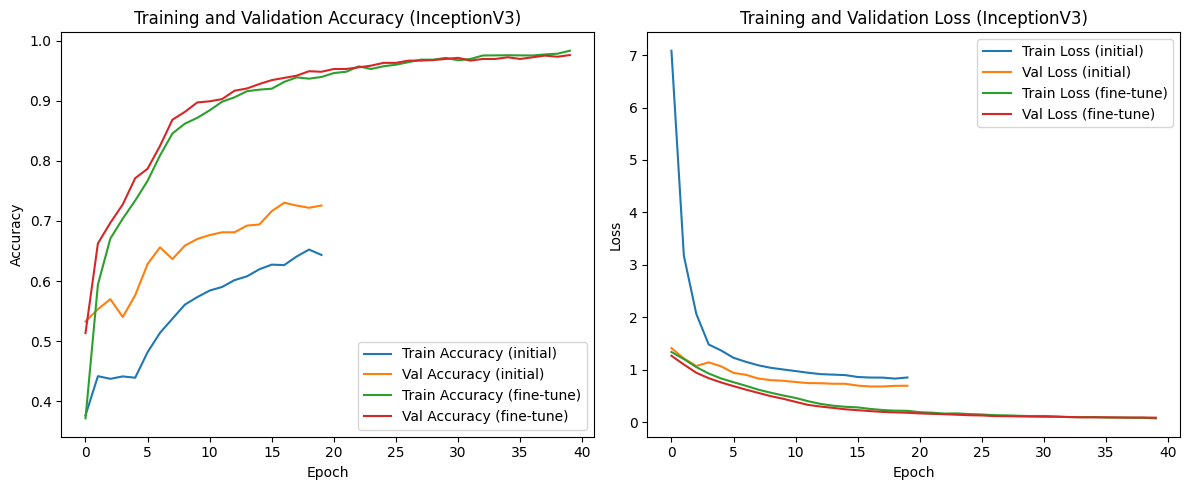

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(inception_history.history['accuracy'], label='Train Accuracy (initial)')
plt.plot(inception_history.history['val_accuracy'], label='Val Accuracy (initial)')
plt.plot(inception_finetune_history.history['accuracy'], label='Train Accuracy (fine-tune)')
plt.plot(inception_finetune_history.history['val_accuracy'], label='Val Accuracy (fine-tune)')
plt.title('Training and Validation Accuracy (InceptionV3)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(inception_history.history['loss'], label='Train Loss (initial)')
plt.plot(inception_history.history['val_loss'], label='Val Loss (initial)')
plt.plot(inception_finetune_history.history['loss'], label='Train Loss (fine-tune)')
plt.plot(inception_finetune_history.history['val_loss'], label='Val Loss (fine-tune)')
plt.title('Training and Validation Loss (InceptionV3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import load_model


best_inception_model = load_model('inception_finetuned.h5')


inception_test_loss, inception_test_acc = best_inception_model.evaluate(test_generator, verbose=1)

print(f" InceptionV3 Test Accuracy: {inception_test_acc:.4f}")
print(f" InceptionV3 Test Loss: {inception_test_loss:.4f}")


34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.9857 - loss: 0.0555
✅ InceptionV3 Test Accuracy: 0.9852
📉 InceptionV3 Test Loss: 0.0599


**Download Best Model To Use In Streamlit**

In [ ]:
from google.colab import files
files.download('inception_finetuned.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Metrics for best InceptionV3 model**

**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_probs = best_inception_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


print(classification_report(y_true, y_pred, target_names=classes))


34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       246
  meningioma       0.98      0.97      0.97       266
     notumor       1.00      1.00      1.00       300
   pituitary       0.98      0.99      0.98       267

    accuracy                           0.99      1079
   macro avg       0.98      0.98      0.98      1079
weighted avg       0.99      0.99      0.99      1079



**Confusion Matrix**

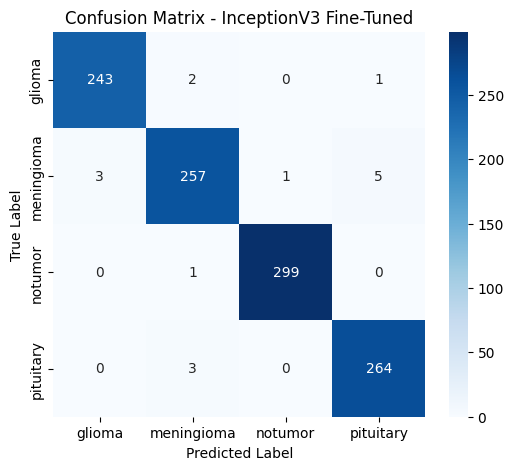

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - InceptionV3 Fine-Tuned')
plt.show()


**ROC Curve**

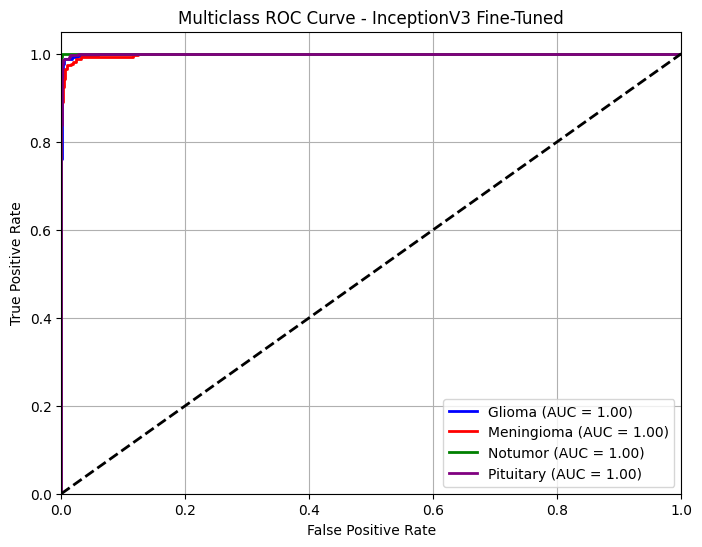

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


y_true_binary = label_binarize(y_true, classes=[0, 1, 2, 3])

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'purple']
for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{classes[i].capitalize()} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - InceptionV3 Fine-Tuned')
plt.legend(loc="lower right")
plt.grid()
plt.show()


### **Grid search for Inception V3**

*Grid Search was attempted for InceptionV3, yet best validation results did not generate higher test performance than original configuration. Therefore, data augmentation and learning rate scheduler was applied to original InceptionV3 configuration to improve accuracy and minimize loss*